In [2]:
import requests
import pandas as pd
import os
import json

def load_data_from_api():
    # 1. 저장 폴더 생성 (오류 방지를 위해 exist_ok=True 설정)
    os.makedirs('data', exist_ok=True)

    # 2. API 호출 (50개 추출 권장 반영)
    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming/?limit=50"

    try:
        print("데이터를 가져오는 중...")
        response = requests.get(url, timeout=10) # 타임아웃 설정으로 무한 대기 방지
        response.raise_for_status()
        data = response.json()

        # 3. JSON 파일 저장
        with open('data/launches.json', 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)

        # 4. DataFrame 변환 및 반환
        # 결과 리스트가 'results' 키 안에 있으므로 이를 추출
        df = pd.DataFrame(data.get('results', []))
        print(f"✅ 성공: {len(df)}개의 데이터를 'data/launches.json'에 저장했습니다.")
        return df

    except Exception as e:
        print(f"❌ 단계 1 오류 발생: {e}")
        return None

# 실행
launch_df = load_data_from_api()
if launch_df is not None:
    display(launch_df.head())

데이터를 가져오는 중...
✅ 성공: 50개의 데이터를 'data/launches.json'에 저장했습니다.


,id,url,launch_library_id,slug,name,status,net,window_end,window_start,inhold,...,failreason,hashtag,launch_service_provider,rocket,mission,pad,webcast_live,image,infographic,program
0,2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd,https://ll.thespacedevs.com/2.0.0/launch/2e3e3...,NaN,long-march-8a-satnet-leo-group-20,Long March 8A | SatNet LEO Group 20,"{'id': 3, 'name': 'Success'}",2026-03-12T19:48:00Z,2026-03-12T20:05:00Z,2026-03-12T19:40:00Z,False,...,,None,"{'id': 88, 'url': 'https://ll.thespacedevs.com...","{'id': 8933, 'configuration': {'id': 518, 'lau...","{'id': 7528, 'launch_library_id': None, 'name'...","{'id': 218, 'url': 'https://ll.thespacedevs.co...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,[]
1,1d24bfe7-d524-41f0-85de-09e967618710,https://ll.thespacedevs.com/2.0.0/launch/1d24b...,NaN,long-march-2d-shiyan-30-03-04,Long March 2D | Shiyan 30 03-04,"{'id': 3, 'name': 'Success'}",2026-03-12T22:33:00Z,2026-03-12T22:46:00Z,2026-03-12T22:25:00Z,False,...,,None,"{'id': 88, 'url': 'https://ll.thespacedevs.com...","{'id': 8934, 'configuration': {'id': 17, 'laun...","{'id': 7529, 'launch_library_id': None, 'name'...","{'id': 66, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,[]
2,6f2868b8-1000-48e5-893b-700c1371b4fb,https://ll.thespacedevs.com/2.0.0/launch/6f286...,NaN,falcon-9-block-5-starlink-group-10-48,Falcon 9 Block 5 | Starlink Group 10-48,"{'id': 1, 'name': 'Go'}",2026-03-13T12:10:40Z,2026-03-13T14:00:00Z,2026-03-13T10:00:00Z,False,...,,None,"{'id': 121, 'url': 'https://ll.thespacedevs.co...","{'id': 8928, 'configuration': {'id': 164, 'lau...","{'id': 7522, 'launch_library_id': None, 'name'...","{'id': 80, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,"[{'id': 25, 'url': 'https://ll.thespacedevs.co..."
3,d44f47c7-5e3e-40fb-9d10-b6e851acf81a,https://ll.thespacedevs.com/2.0.0/launch/d44f4...,NaN,falcon-9-block-5-starlink-group-17-31,Falcon 9 Block 5 | Starlink Group 17-31,"{'id': 1, 'name': 'Go'}",2026-03-13T14:33:50Z,2026-03-13T14:58:00Z,2026-03-13T10:58:00Z,False,...,,None,"{'id': 121, 'url': 'https://ll.thespacedevs.co...","{'id': 8922, 'configuration': {'id': 164, 'lau...","{'id': 7514, 'launch_library_id': None, 'name'...","{'id': 16, 'url': 'https://ll.thespacedevs.com...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,"[{'id': 25, 'url': 'https://ll.thespacedevs.co..."
4,f8766455-2b03-4629-a36e-b931c8b4a6c5,https://ll.thespacedevs.com/2.0.0/launch/f8766...,NaN,long-march-6a-unknown-payload,Long March 6A | Unknown Payload,"{'id': 1, 'name': 'Go'}",2026-03-15T13:20:00Z,2026-03-15T13:35:00Z,2026-03-15T13:14:00Z,False,...,,None,"{'id': 88, 'url': 'https://ll.thespacedevs.com...","{'id': 8935, 'configuration': {'id': 478, 'lau...","{'id': 7530, 'launch_library_id': None, 'name'...","{'id': 200, 'url': 'https://ll.thespacedevs.co...",False,https://thespacedevs-prod.nyc3.digitaloceanspa...,None,[]


단계 1: 데이터 수집 및 JSON 저장 (Extract & Load)목적: 외부 API 서버로부터 원본 데이터를 가져와 로컬 환경에 물리적인 파일로 저장하는 단계입니다.주요 작업:requests 모듈을 사용해 https://ll.thespacedevs.com/2.0.0/launch/upcoming URL로 데이터를 요청합니다.서버의 응답 결과를 launches.json이라는 파일로 저장하여, 매번 API를 호출하지 않아도 되도록 '데이터 보관소' 역할을 하는 폴더를 생성합니다.pandas.DataFrame으로 변환하여 데이터가 표 형태로 잘 들어왔는지 구조를 확인합니다.

In [4]:
import requests
import os
import json

def get_pictures():
    # 1. 이미지 저장 폴더 생성 [cite: 9, 21]
    os.makedirs('image', exist_ok=True)

    # 2. 단계 1에서 저장한 launches.json 파일을 다시 읽기 [cite: 18]
    try:
        if not os.path.exists('data/launches.json'):
            print("❌ 오류: 'data/launches.json' 파일이 없습니다. 단계 1을 먼저 실행하세요.")
            return

        with open('data/launches.json', 'r', encoding='utf-8') as f:
            data = json.load(f)

        # 'results' 리스트 추출 (데이터가 없을 경우 빈 리스트 반환)
        launches = data.get('results', [])
        print(f"총 {len(launches)}개의 데이터에서 이미지 추출을 시작합니다.")

        for i, launch in enumerate(launches):
            # 3. 데이터 내의 특정 정보(이미지 URL) 추출 [cite: 10, 19]
            image_url = launch.get('image')

            # 이미지가 없는 경우를 대비한 예외 처리 [cite: 20]
            if not image_url:
                print(f"   - {i}번 항목: 이미지 URL 없음 (Skipped)")
                continue

            try:
                # 4. 이미지 파일을 다운로드하여 저장 [cite: 21]
                # 네트워크 연결 오류나 유효하지 않은 URL에 대한 예외 처리 포함 [cite: 22, 35]
                headers = {'User-Agent': 'Mozilla/5.0'} # 차단 방지를 위한 헤더 추가
                img_res = requests.get(image_url, timeout=15, headers=headers)
                img_res.raise_for_status()

                # 파일 확장자 정제 (.jpg, .png 등)
                ext = image_url.split('.')[-1].split('?')[0].lower()
                if ext not in ['jpg', 'jpeg', 'png', 'webp']:
                    ext = 'jpg' # 기본값 설정

                filename = f"image/launch_{i}.{ext}"

                with open(filename, 'wb') as f:
                    f.write(img_res.content)
                print(f"✅ {i}번 저장 완료: {filename}")

            except Exception as e:
                # 개별 이미지 다운로드 실패 시 전체 프로세스가 멈추지 않도록 예외 처리
                print(f"⚠️ {i}번 다운로드 실패 ({image_url[:30]}...): {e}")

        print("\n✨ 모든 작업이 완료되었습니다. 'image' 폴더를 확인하세요.")

    except Exception as e:
        print(f"❌ 단계 2 시스템 오류: {e}")

# 실행
get_pictures()

총 50개의 데이터에서 이미지 추출을 시작합니다.
✅ 0번 저장 완료: image/launch_0.jpeg
✅ 1번 저장 완료: image/launch_1.jpeg
✅ 2번 저장 완료: image/launch_2.png
✅ 3번 저장 완료: image/launch_3.png
✅ 4번 저장 완료: image/launch_4.jpeg
✅ 5번 저장 완료: image/launch_5.jpeg
✅ 6번 저장 완료: image/launch_6.png
✅ 7번 저장 완료: image/launch_7.png
✅ 8번 저장 완료: image/launch_8.png
✅ 9번 저장 완료: image/launch_9.jpeg
✅ 10번 저장 완료: image/launch_10.jpeg
✅ 11번 저장 완료: image/launch_11.png
✅ 12번 저장 완료: image/launch_12.jpg
✅ 13번 저장 완료: image/launch_13.png
✅ 14번 저장 완료: image/launch_14.jpeg
✅ 15번 저장 완료: image/launch_15.png
✅ 16번 저장 완료: image/launch_16.jpeg
✅ 17번 저장 완료: image/launch_17.jpeg
✅ 18번 저장 완료: image/launch_18.jpeg
✅ 19번 저장 완료: image/launch_19.jpg
✅ 20번 저장 완료: image/launch_20.jpg
✅ 21번 저장 완료: image/launch_21.jpeg
✅ 22번 저장 완료: image/launch_22.jpeg
✅ 23번 저장 완료: image/launch_23.jpg
✅ 24번 저장 완료: image/launch_24.jpg
✅ 25번 저장 완료: image/launch_25.jpeg
✅ 26번 저장 완료: image/launch_26.jpg
✅ 27번 저장 완료: image/launch_27.jpg
✅ 28번 저장 완료: image/launch_28.jpeg
✅ 29번 저장 완료: image/la

단계 2: 이미지 데이터 추출 및 다운로드 (Transform & Load)목적: 저장된 전체 데이터 중 '이미지 URL'이라는 특정 정보만 골라내어 실제 이미지 파일로 변환하는 단계입니다.주요 작업:앞서 저장한 launches.json 파일을 다시 읽어옵니다.반복문을 통해 각 데이터 항목에서 image URL을 추출합니다.예외 처리: 이미지가 없는 경우나 네트워크 연결 오류, 유효하지 않은 URL 등에 대비하여 try-except 구문을 반드시 사용해야 합니다.추출한 URL을 통해 이미지 파일을 다운로드하고 별도의 이미지 전용 폴더에 저장합니다.


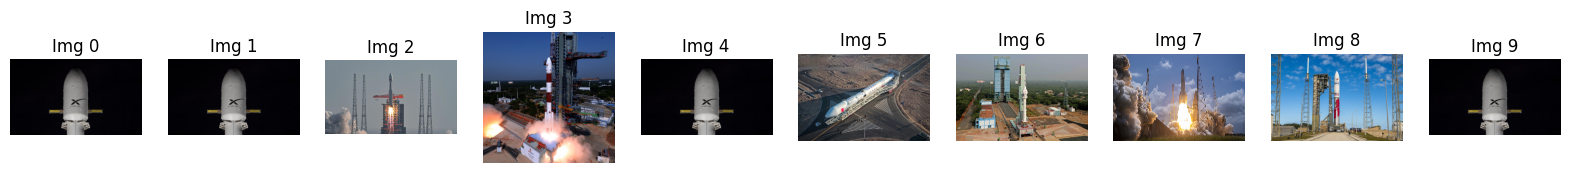

In [7]:
import matplotlib.pyplot as plt
import PIL.Image as Image

def visualize_images():
    # image 폴더 내 파일 목록 가져오기
    img_list = [f for f in os.listdir('image') if f.endswith(('jpg', 'png', 'jpeg'))]

    if not img_list:
        print("시각화할 이미지가 없습니다.")
        return

    # 최대 10개만 출력 (이미지가 너무 많으면 코랩이 느려짐)
    num_show = min(10, len(img_list))
    plt.figure(figsize=(20, 4))

    for i in range(num_show):
        img_path = os.path.join('image', img_list[i])
        img = Image.open(img_path)
        plt.subplot(1, num_show, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Img {i}")
    plt.show()

# 실행
visualize_images()

단계 3: 이미지 데이터 읽어와 시각화 (Check)목적: 단계 2에서 다운로드한 이미지 파일들이 실제 로컬 디렉터리에 정상적으로 존재하는지 눈으로 확인하는 과정입니다.주요 작업:폴더 내의 이미지 파일들을 불러와 화면에 출력하여 데이터 수집이 성공적이었음을 증명합니다.

In [6]:
def titanic_etl_simple():
    print("\n--- 심화 과제: Titanic 데이터 분석 ---")
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

    try:
        # 1. 데이터 추출 (Extract)
        titanic_df = pd.read_csv(url)

        # 2. 데이터 확인 (Transform 전 단계)
        print("데이터프레임 상단 5행:")
        display(titanic_df.head())

        # 3. 결측치 확인 등 기초 분석
        print(f"\n데이터 요약:")
        print(titanic_df.describe())

    except Exception as e:
        print(f"Titanic 데이터 로드 중 오류: {e}")

# 실행
titanic_etl_simple()


--- 심화 과제: Titanic 데이터 분석 ---
데이터프레임 상단 5행:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



데이터 요약:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


단계 4: 심화 과제 (Practice)목적: 앞서 배운 ETL 과정을 새로운 데이터셋에 스스로 적용해 보며 응용력을 기르는 단계입니다.선택 옵션:Titanic 데이터: CSV 형식의 데이터를 가져와 데이터프레임으로 분석합니다.Scikit-learn 데이터: iris 또는 california_housing 같은 공공 데이터셋을 불러와 탐색해 봅니다.
